In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO


pep_hits_long = pd.read_csv('long_091826.csv')

In [2]:
lassa = pep_hits_long[pep_hits_long['species'] == 'Mammarenavirus lassaense'].copy()

## importing the reference sequences fetched from UniProt (UP000002473_11622.fasta)

In [3]:
records = list(SeqIO.parse('UP000002473_11622_LASV_Josiah_reference.fasta', 'fasta'))

for r in records:
    print(r.id, len(r.seq))

sp|O09705|L_LASSJ 2218
sp|O73557|Z_LASSJ 99
sp|P08669|GLYC_LASSJ 491
sp|P13699|NCAP_LASSJ 569


In [4]:
reference_by_protein = {
    "polymerase": str(next(r.seq for r in records if "O09705" in r.id)),
    "glycoprotein": str(next(r.seq for r in records if "P08669" in r.id)),
    "nucleoprotein": str(next(r.seq for r in records if "P13699" in r.id)),
    "z protein": str(next(r.seq for r in records if "O73557" in r.id)),
}

In [5]:
print(lassa['category'].value_counts())
print(lassa['sequence'].nunique())
print(lassa['protein_std'].unique())

category
Household contact    21052
Lassa survivor        9120
US healthy            6612
Name: count, dtype: int64
76
['polymerase' 'glycoprotein' 'nucleoprotein' 'z protein']


## import PairwiseAligner and use BLOSUM62 matrix for local protein alignment

In [6]:
from Bio.Align import PairwiseAligner
from Bio.Align import substitution_matrices

aligner = PairwiseAligner()
aligner.mode = 'local' #want the peptide to find its best location within the reference

aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

## first nucleoprotein

In [7]:
ref = reference_by_protein['z protein']

np = lassa[lassa['protein_std'].eq("z protein")].copy()

unique_np_peptides = np['sequence'].drop_duplicates()

In [8]:
ref

'MGNKQAKAPESKDSPRASLIPDATHLGPQFCKSCWFENKGLVECNNHYLCLNCLTLLLSVSNRCPICKMPLPTKLRPSAAPTAPPTGAADSIRPPPYSP'

## define mapping function

In [9]:
def map_peptide_to_reference(peptide, reference, aligner):
    """
    goal: map a peptide onto a reference protein. 

    output: returns a dictionary containing
    - alignment score
    - reference start/end (1-based)
    - reference positions covered by aligned peptide residues
    """

    #if no exact substring match, use local alignment
    alignment = aligner.align(reference, peptide)[0] #[0] to extract the first and best-scoring Alignment object from the results

    #aligner.align[0].aligned returns the start and end coordinates of the aligned segments for the target and query sequences
    ref_blocks, peptide_blocks = alignment.aligned

    ref_positions = []

    for (ref_start, ref_end), (pep_start, pep_end) in zip(ref_blocks, peptide_blocks):
        
        for i in range(ref_end - ref_start):
            ref_positions.append(ref_start + i + 1) #1-based

    #overall peptide coordinates
    pep_start = peptide_blocks[0][0] + 1
    pep_end = peptide_blocks[-1][1] #take the last block,so -1, in case there are more than one aligned blocks. and [1] for the end

    #total number of peptide residues included in the aligned blocks
    aligned_length = sum(end - start for start, end in peptide_blocks)

    #total number 

    return{
        'score': alignment.score, 
        'ref_start': ref_positions[0],
        'ref_end': ref_positions[-1],
        'ref_positions': ref_positions, 
        'pep_start' : pep_start, 
        'pep_end': pep_end,
        'aligned_length': aligned_length
    }


In [10]:
mapping = []

for peptide in unique_np_peptides:
    result = map_peptide_to_reference(peptide, ref, aligner)

    mapping.append({
        'sequence': peptide, 
        'score': result['score'], 
        'ref_start': result['ref_start'], 
        'ref_end': result['ref_end'], 
        'ref_positions': result['ref_positions'], 
        'pep_start': result['pep_start'], 
        'pep_end': result['pep_end'], 
        'aligned_pep_length': result['aligned_length']

    })

np_mapping = pd.DataFrame(mapping)

In [11]:
#check the length of peptide alignment, should be ~46

np_mapping['alignment_length'] = np_mapping['ref_positions'].str.len()

np_mapping['alignment_length'].describe()

count     2.0
mean     46.0
std       0.0
min      46.0
25%      46.0
50%      46.0
75%      46.0
max      46.0
Name: alignment_length, dtype: float64

In [12]:
np_mapping.sort_values('aligned_pep_length').head(2)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,alignment_length
0,MGGKQTKSSKETDSPRASLIPDASHMGPQFCKSCWFENKGLVECNN,216.0,1,46,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,46,46,46
1,MGNRQAKSTKVDEHQRACLVPDASHLGPQFCKSCWFENRGLVECNN,197.0,1,46,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,46,46,46


In [13]:
#inspect the shortest mappings: 
np_mapping.sort_values("alignment_length").head(10)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,alignment_length
0,MGGKQTKSSKETDSPRASLIPDASHMGPQFCKSCWFENKGLVECNN,216.0,1,46,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,46,46,46
1,MGNRQAKSTKVDEHQRACLVPDASHLGPQFCKSCWFENRGLVECNN,197.0,1,46,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,46,46,46


## merging the mapping back to the individual-level dataframe


In [14]:
np = np.merge(np_mapping, on='sequence', how='left')

In [15]:
np.shape

(968, 21)

## .explode() turns one peptide/individual row to one row per amino-acid position covered by that peptide

In [16]:
np_residues = np.explode('ref_positions').rename(columns={'ref_positions': 'position'})

## keep only reactive peptides

In [17]:
reactive_residues = np_residues[np_residues['reactive']].copy()

## now we have the people and amino acid positions at which they have nucleoprotein antibody reactivity. But we need to remove contributions to the same amino-acid position. each individual can contribute at most one to a given amino acid position. 

In [18]:
reactive_residues = reactive_residues[['individual', 'cohort', 'category', 'position']].drop_duplicates()

In [19]:
reactive_residues['individual'].unique() #no US healthies, as expected

array(['C-130-2_3_C3', 'C-470-3_2_F8', 'S-463_SA2_F8', 'C-178-1_1_E1',
       'C-191-3_1_A3', 'C-462-2_2_D4', 'C-472-3_2_E9', 'C-475-1_3_G6',
       'C-499-1_2_C2', 'S-117_SA1_A6', 'S-141_SA1_D7', 'S-442_SA2_F3',
       'S-498_SA1_H6', 'C-120-1_4_G7', 'C-446-2_2_E7', 'C-446-3_2_G2',
       'S-109_SA1_B1', 'S-466_SA1_I2', 'C-437-2_2_D8', 'C-439-1_1_I5',
       'C-442-1_2_E2', 'C-457-1_1_G9', 'C-483-3_1_E6', 'C-487-1_1_E2',
       'C-498-3_1_A4', 'C-115-2_3_B7', 'C-117-2_4_I2', 'C-120-2_1_F6',
       'C-130-1_1_I1', 'C-138-2_1_E5', 'C-148-1_1_G1', 'C-149-2_1_I9',
       'C-187-2_1_G5', 'C-192-2_1_D7', 'C-437-1_2_H2', 'C-438-3_3_A3',
       'C-444-1_2_D9', 'C-468-3_7_H1', 'C-470-1_3_A6', 'C-488-2_3_F7',
       'C-504-2_5_C1', 'C-505-3_3_I1', 'C-511-2_4_A2', 'S-133_SA1_D1',
       'S-191_SA1_F3', 'S-434_SA2_F5', 'S-451_SA2_E7', 'S-454_SA2_I5',
       'S-483_SA2_D9', 'S-497_SA1_H5'], dtype=object)

## calculate number of individuals in each category

In [20]:
group_sizes = (
    np[['individual', 'cohort', 'category']].drop_duplicates().groupby(['cohort', 'category']).size().rename('n_individuals').reset_index()
)

group_sizes

,cohort,category,n_individuals
0,HBDB,US healthy,87
1,SL,Household contact,277
2,SL,Lassa survivor,120


## now count reactive individuals at each position

In [21]:
position_counts = (
    reactive_residues.groupby(['cohort', 'category', 'position'])['individual'] #reactive residues only include SL individuals
    .nunique()
    .rename('n_seroreactive')
    .reset_index()
)

position_counts.head(2)

,cohort,category,position,n_seroreactive
0,SL,Household contact,1,36
1,SL,Household contact,2,36


In [22]:
position_summary = position_counts.merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary.head(2)

,cohort,category,position,n_seroreactive,n_individuals
0,SL,Household contact,1,36,277
1,SL,Household contact,2,36,277


In [23]:
position_summary['pct_seroreactive'] = (
    position_summary['n_seroreactive'] / position_summary['n_individuals'] * 100
)

In [24]:
position_summary.head(3)

,cohort,category,position,n_seroreactive,n_individuals,pct_seroreactive
0,SL,Household contact,1,36,277,12.99639
1,SL,Household contact,2,36,277,12.99639
2,SL,Household contact,3,36,277,12.99639


## add positions with zero seroreactivity 

In [25]:
all_positions = pd.DataFrame({'position': range(1, len(ref) + 1)}) #initiate a dataframe with one column

groups = np[['cohort', 'category']].drop_duplicates()

complete_grid = groups.merge(all_positions, how='cross')

complete_grid.head(2)

,cohort,category,position
0,SL,Household contact,1
1,SL,Household contact,2


In [26]:
position_summary = complete_grid.merge(
    position_summary,
    on=["cohort", "category", "position"],
    how="left"
)

position_summary["n_seroreactive"] = (
    position_summary["n_seroreactive"]
    .fillna(0)
)

position_summary = position_summary.drop(columns='n_individuals').merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary['pct_seroreactive'] = 100 * position_summary['n_seroreactive'] / position_summary['n_individuals']

In [27]:
position_summary

,cohort,category,position,n_seroreactive,pct_seroreactive,n_individuals
0,SL,Household contact,1,36.0,12.99639,277
1,SL,Household contact,2,36.0,12.99639,277
2,SL,Household contact,3,36.0,12.99639,277
3,SL,Household contact,4,36.0,12.99639,277
4,SL,Household contact,5,36.0,12.99639,277
...,...,...,...,...,...,...
292,HBDB,US healthy,95,0.0,0.00000,87
293,HBDB,US healthy,96,0.0,0.00000,87
294,HBDB,US healthy,97,0.0,0.00000,87
295,HBDB,US healthy,98,0.0,0.00000,87


## Now going to plot the % of cohort/ category reactive to the amino acid positions of the nucleoprotein

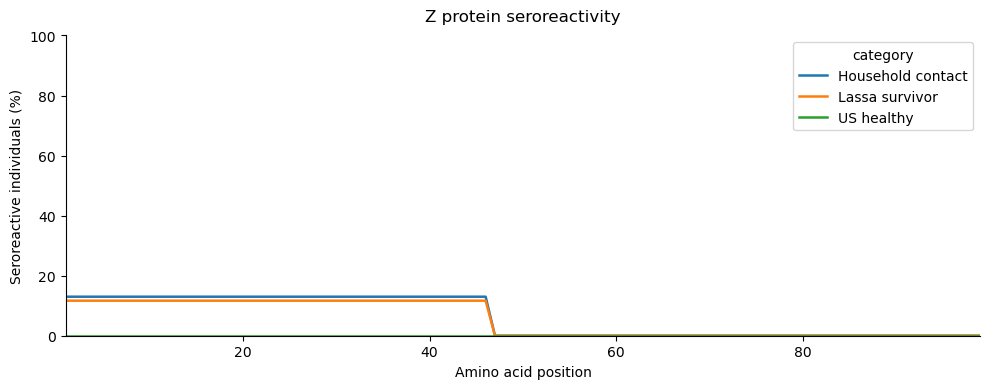

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data= position_summary, 
    x='position', 
    y='pct_seroreactive', 
    hue='category', 
    linewidth=1.8, 
    ax=ax
)

ax.set_xlabel('Amino acid position')
ax.set_ylabel('Seroreactive individuals (%)')
ax.set_xlim(1, len(ref)) #minimum and maximum position
ax.set_ylim(0,  100)

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title('Z protein seroreactivity', y=1.02)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('z_protein_reactivity.svg', format='svg')
plt.show()